#### **Dog Breed Recognition with Transfer Learning in Keras**

This notebook trains a simple dog breed classifier using transfer learning.

The important idea is this: each folder inside `data/TRAIN` is treated as one class automatically. If you add a new breed folder later, Keras will include it as a new class the next time you run the notebook.

#### **Run this notebook in COLAB**

<a target="_blank" href="https://colab.research.google.com/github/castorgit/AI-Course-Examples/blob/main/15-NoCode-examples/HW2/dog_breed_transfer_learning_keras.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

#### **Pointing to your Data in Drive**
(1) Dowload the dataset<br>
(2) Create a /data/ folder in your Google Drive<br>
(3) put all the data in that folder, make sure you end up with this structure<br>

data<br>
├── TRAIN<br>
│   ├── German_Shepherd<br>
│   ├── Chihuahua<br>
│   └── ...<br>
└── TEST<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;└── (All your test photos here)

#### **Definitions**

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Optional support for AVIF/HEIC images if these packages are installed.
try:
    import pillow_avif  # noqa: F401
except ImportError:
    pass

try:
    from pillow_heif import register_heif_opener
    register_heif_opener()
except ImportError:
    pass

print("TensorFlow version:", tf.__version__)

2026-05-24 18:51:05.387756: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-24 18:51:05.429391: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/jaumemanero/RL/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.12) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_c

TensorFlow version: 2.20.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
DATA_DIR = Path('/content/drive/MyDrive/data')   # each student's own "data" folder

In [2]:
# This notebook is inside HW2, so these paths are relative to HW2.
# DATA_DIR = Path("data") >>> use this for local path to data folder

TRAIN_DIR = DATA_DIR / "TRAIN"
TEST_DIR = DATA_DIR / "TEST"

print("Training folder:", TRAIN_DIR.resolve())
print("Test folder:", TEST_DIR.resolve())

Training folder: /home/jaumemanero/_DEVELOPMENT/_Notebooks/AI-Course-Examples/15-NoCode-examples/HW2/data/TRAIN
Test folder: /home/jaumemanero/_DEVELOPMENT/_Notebooks/AI-Course-Examples/15-NoCode-examples/HW2/data/TEST


---
#### **Load Training Data**
---

`image_dataset_from_directory` reads the folder names inside `data/TRAIN` and turns them into class labels.

Example:

```text
data/TRAIN/Beagle          -> class: Beagle
data/TRAIN/Dalmatian       -> class: Dalmatian
data/TRAIN/Golden_Retriever -> class: Golden_Retriever
```

So adding a new folder like `data/TRAIN/Boxer` automatically adds a new class.

In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 42

train_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

val_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Number of classes:", num_classes)
print("Classes:")
for name in class_names:
    print("-", name)

Found 838 files belonging to 29 classes.
Using 671 files for training.
Found 838 files belonging to 29 classes.
Using 167 files for validation.
Number of classes: 29
Classes:
- Beagle
- Bearnese_Mountain_dog
- Bulldog
- Cane corso
- Chinese_crested
- Corgi
- Dachshund
- Dalmatian
- Golden_Retriever
- Labrador
- Maltese_Terrier
- Mastin Napolitano
- Mastin_tibetano
- Pastore Maremmano
- Pechinese
- Schnoxie
- Shih_Tzu
- Siberian Husky
- Vizsla
- Wire-haired dachshund
- Xoloitzcuintle
- Yorkshire
- chiuaua
- collie
- german-shepherd
- irish setter
- malamute
- schnauzer-gigante
- west highland


2026-05-24 18:51:08.273696: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (100)


---
#### **Show a few example images**
---

2026-05-24 18:51:09.754059: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


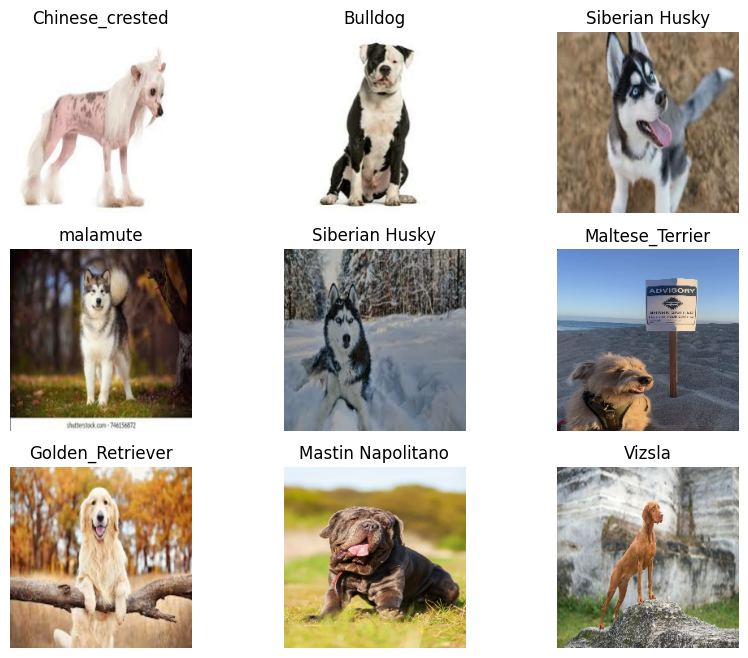

In [4]:
plt.figure(figsize=(10, 8))

for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

---
#### **Trick to speed up access to dataset**
---

These lines make training smoother by preparing batches while the model is training.

In [5]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

---
#### **Transfer Learning Model**
---
We use MobileNetV2, a model that was already trained on ImageNet.

We freeze the original MobileNetV2 layers and only train a small new classifier on top for our dog breeds.

In [6]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ],
    name="data_augmentation",
)

base_model = keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet",
)
base_model.trainable = False

inputs = keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 29)             │        37,149 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,295,133 (8.76 MB)

 Trainable params: 37,149 (145.11 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

---
### **Train the Model**
---

This is the training of the model. It takes some time but just a fraction of a training from scratch as we are doing transfer learning

In [7]:
EPOCHS = 8

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
)

Epoch 1/8
42/42 ━━━━━━━━━━━━━━━━━━━━ 7s 122ms/step - accuracy: 0.3741 - loss: 2.3124 - val_accuracy: 0.7725 - val_loss: 0.9422
Epoch 2/8
42/42 ━━━━━━━━━━━━━━━━━━━━ 7s 159ms/step - accuracy: 0.8256 - loss: 0.7330 - val_accuracy: 0.9102 - val_loss: 0.4654
Epoch 3/8
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - accuracy: 0.8867 - loss: 0.4375 - val_accuracy: 0.9401 - val_loss: 0.3460
Epoch 4/8
42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - accuracy: 0.9270 - loss: 0.3318 - val_accuracy: 0.9401 - val_loss: 0.2778
Epoch 5/8
42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step - accuracy: 0.9270 - loss: 0.2613 - val_accuracy: 0.9341 - val_loss: 0.2670
Epoch 6/8
42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step - accuracy: 0.9657 - loss: 0.1927 - val_accuracy: 0.9401 - val_loss: 0.2405
Epoch 7/8
42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step - accuracy: 0.9434 - loss: 0.1807 - val_accuracy: 0.9461 - val_loss: 0.2257
Epoch 8/8
42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step - accuracy: 0.9434 - loss: 0.1756 - val_accuracy: 0.9401 - v

---
#### **Plot training history**
---

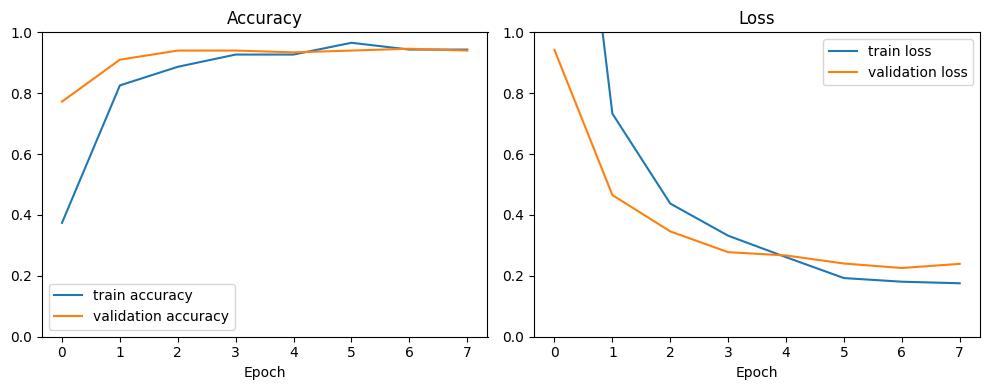

In [8]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="validation accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylim(0,1)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="validation loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylim(0,1)
plt.legend()

plt.tight_layout()

#### **Helper Function Predict one image**

This helper function loads one image, resizes it, asks the model for a prediction, and returns the most likely dog breed.

In [10]:
def predict_image(image_path):
    img = keras.utils.load_img(image_path, target_size=IMG_SIZE)
    img_array = keras.utils.img_to_array(img)
    img_batch = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_batch, verbose=0)[0]
    predicted_index = np.argmax(predictions)
    predicted_class = class_names[predicted_index]
    confidence = predictions[predicted_index]

    return predicted_class, confidence

#### **Predict all  photos in TEST**

This loops through every image in `data/TEST`, prints the filename and classification, and displays the image.

In [11]:
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp", ".avif"}
test_images = sorted(
    path for path in TEST_DIR.iterdir()
    if path.is_file() and path.suffix.lower() in image_extensions
)

print("Number of test images:", len(test_images))

Number of test images: 41


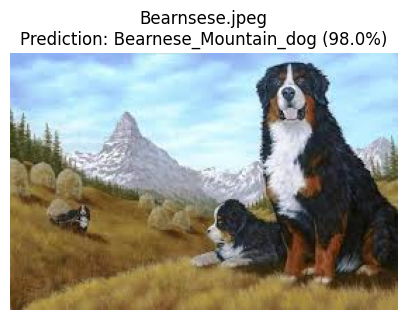

Bearnsese.jpeg: Bearnese_Mountain_dog (98.0%)


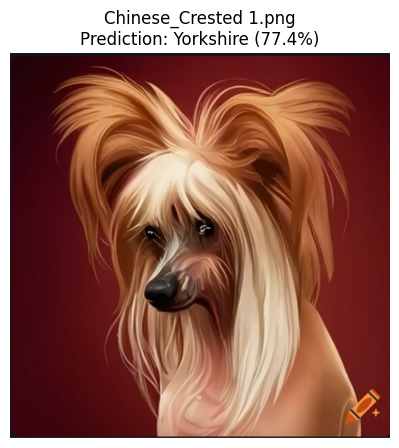

Chinese_Crested 1.png: Yorkshire (77.4%)


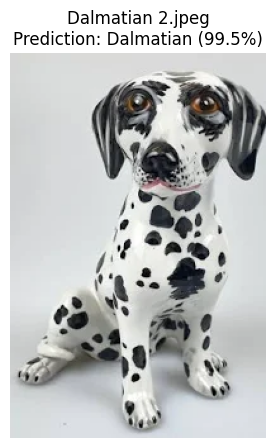

Dalmatian 2.jpeg: Dalmatian (99.5%)


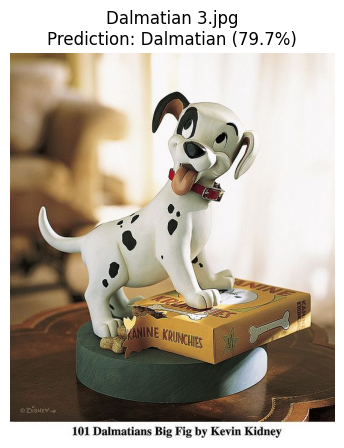

Dalmatian 3.jpg: Dalmatian (79.7%)


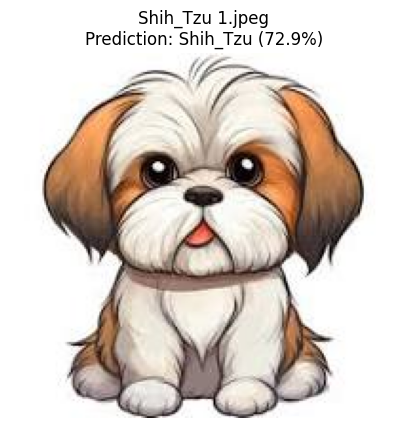

Shih_Tzu 1.jpeg: Shih_Tzu (72.9%)


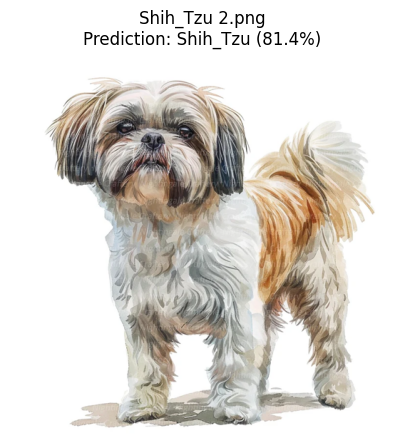

Shih_Tzu 2.png: Shih_Tzu (81.4%)


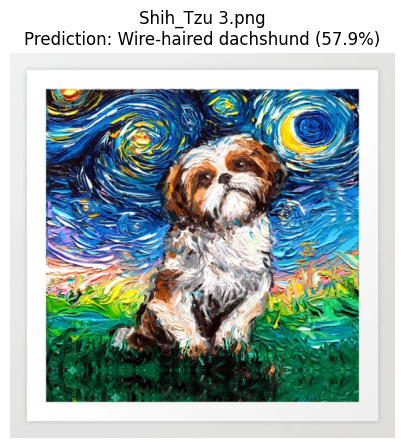

Shih_Tzu 3.png: Wire-haired dachshund (57.9%)


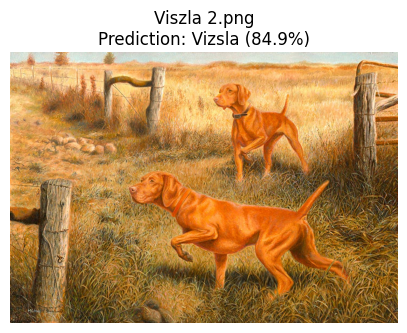

Viszla 2.png: Vizsla (84.9%)
Could not read Voszla 1.avif: cannot identify image file <_io.BytesIO object at 0x76a709de9b20>


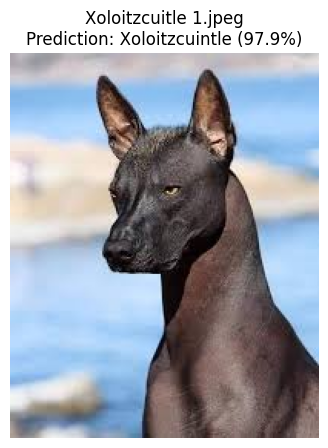

Xoloitzcuitle 1.jpeg: Xoloitzcuintle (97.9%)


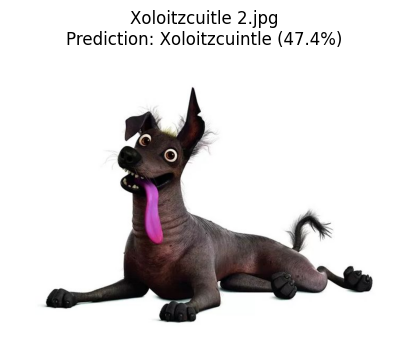

Xoloitzcuitle 2.jpg: Xoloitzcuintle (47.4%)


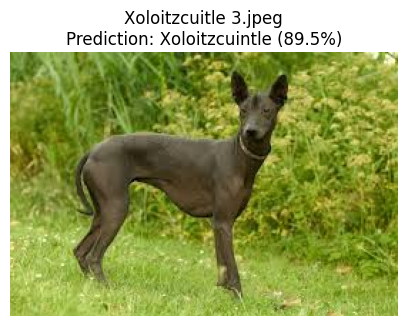

Xoloitzcuitle 3.jpeg: Xoloitzcuintle (89.5%)


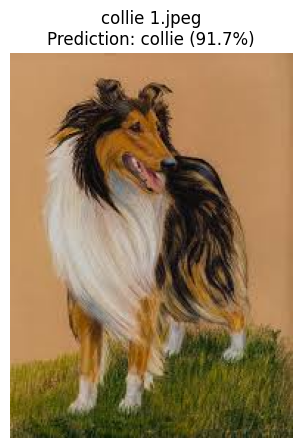

collie 1.jpeg: collie (91.7%)


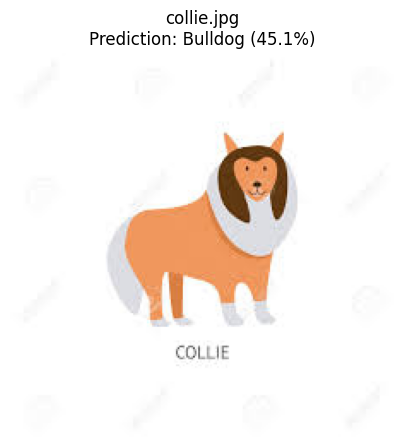

collie.jpg: Bulldog (45.1%)


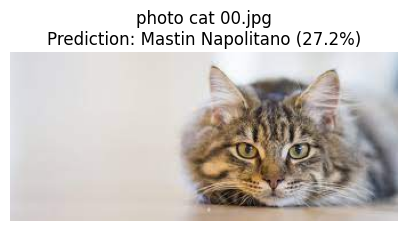

photo cat 00.jpg: Mastin Napolitano (27.2%)


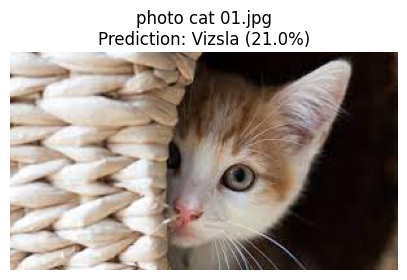

photo cat 01.jpg: Vizsla (21.0%)


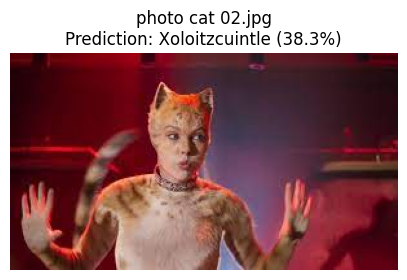

photo cat 02.jpg: Xoloitzcuintle (38.3%)


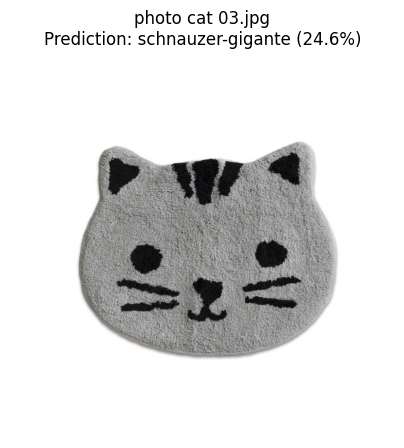

photo cat 03.jpg: schnauzer-gigante (24.6%)


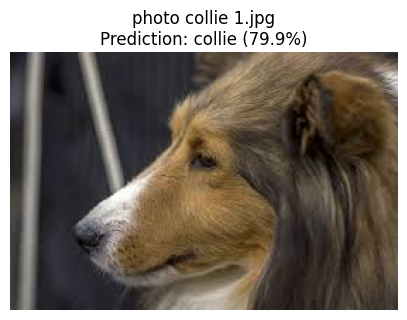

photo collie 1.jpg: collie (79.9%)


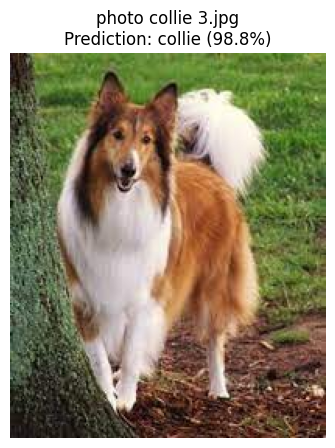

photo collie 3.jpg: collie (98.8%)


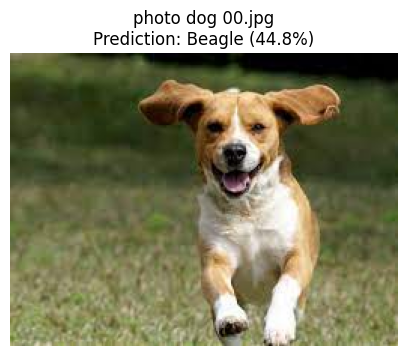

photo dog 00.jpg: Beagle (44.8%)


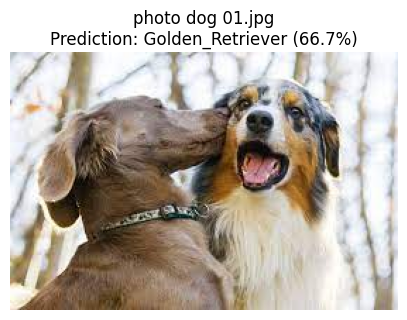

photo dog 01.jpg: Golden_Retriever (66.7%)


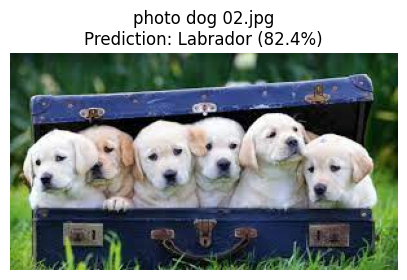

photo dog 02.jpg: Labrador (82.4%)


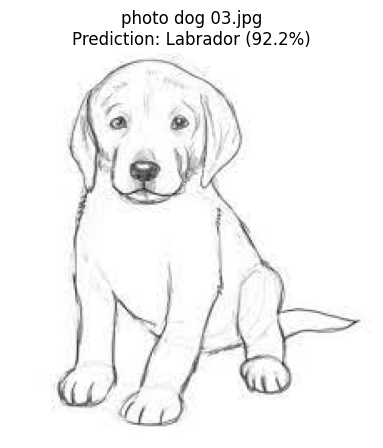

photo dog 03.jpg: Labrador (92.2%)


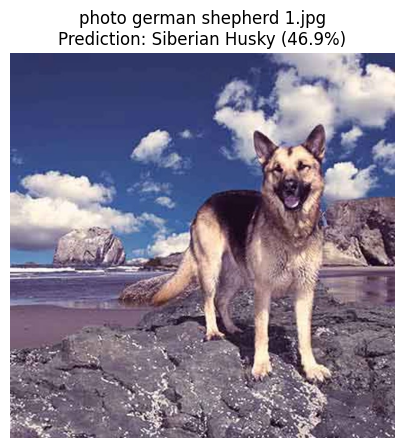

photo german shepherd 1.jpg: Siberian Husky (46.9%)


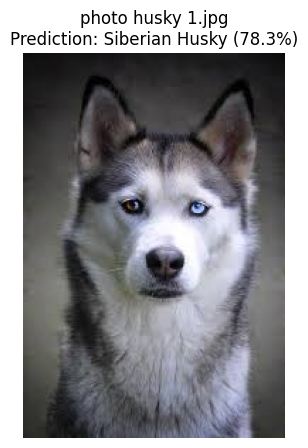

photo husky 1.jpg: Siberian Husky (78.3%)


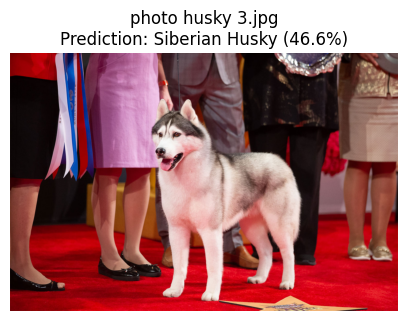

photo husky 3.jpg: Siberian Husky (46.6%)


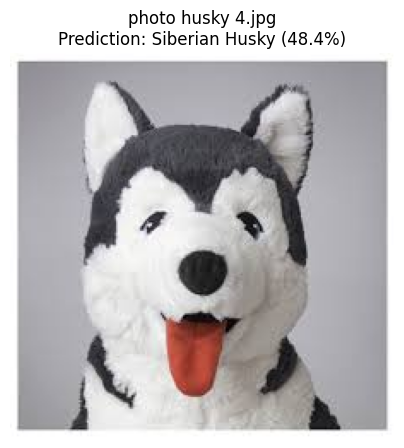

photo husky 4.jpg: Siberian Husky (48.4%)


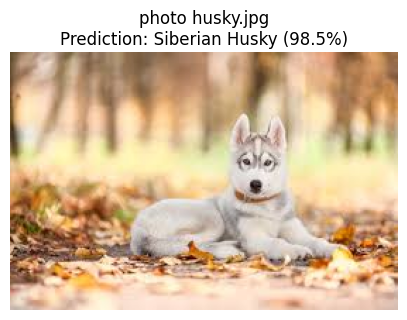

photo husky.jpg: Siberian Husky (98.5%)


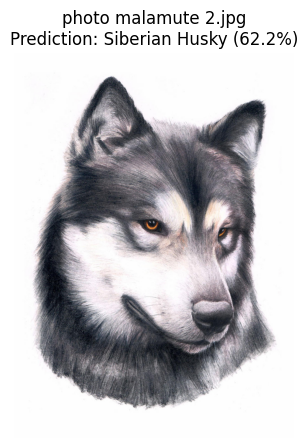

photo malamute 2.jpg: Siberian Husky (62.2%)


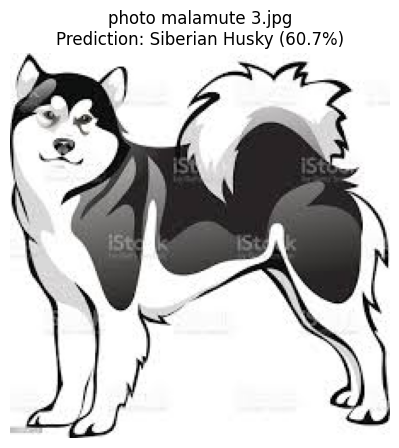

photo malamute 3.jpg: Siberian Husky (60.7%)


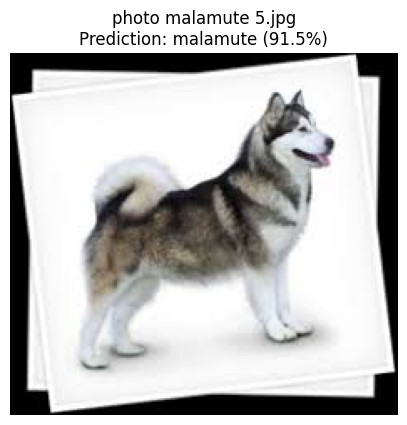

photo malamute 5.jpg: malamute (91.5%)


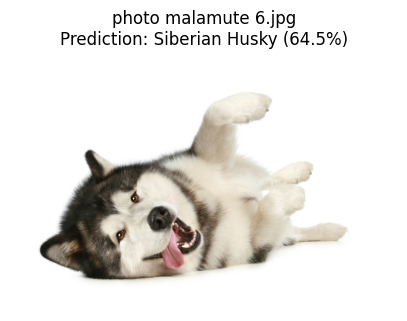

photo malamute 6.jpg: Siberian Husky (64.5%)


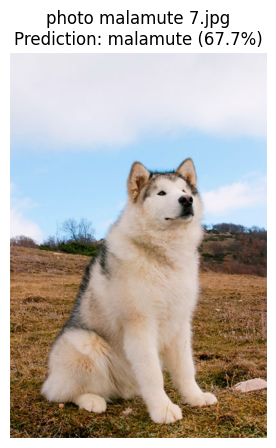

photo malamute 7.jpg: malamute (67.7%)


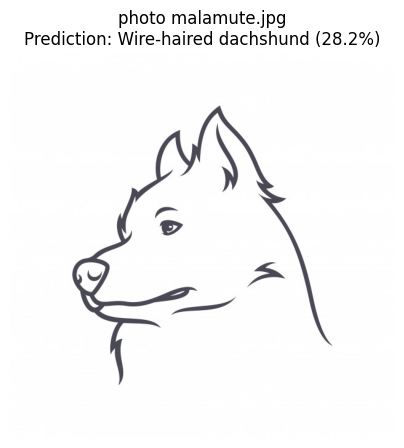

photo malamute.jpg: Wire-haired dachshund (28.2%)


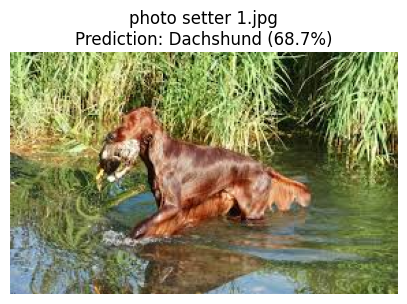

photo setter 1.jpg: Dachshund (68.7%)


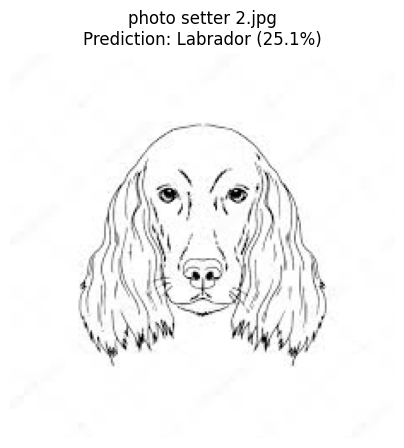

photo setter 2.jpg: Labrador (25.1%)


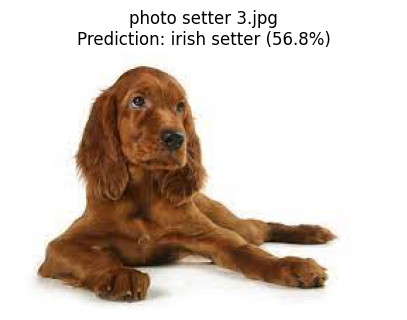

photo setter 3.jpg: irish setter (56.8%)


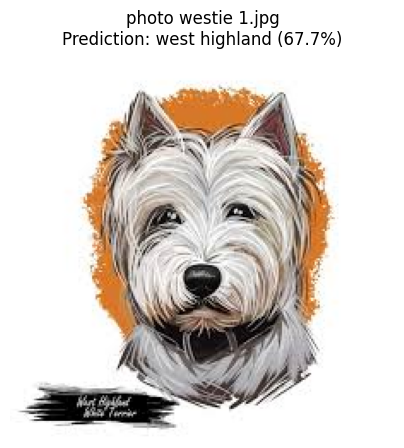

photo westie 1.jpg: west highland (67.7%)


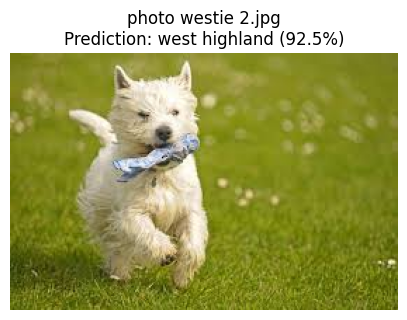

photo westie 2.jpg: west highland (92.5%)


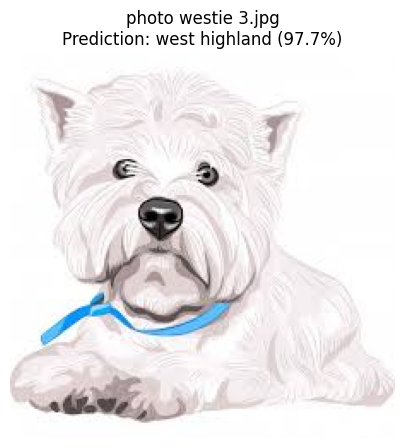

photo westie 3.jpg: west highland (97.7%)


In [12]:
for image_path in test_images:
    try:
        predicted_class, confidence = predict_image(image_path)

        img = keras.utils.load_img(image_path)

        plt.figure(figsize=(5, 5))
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"{image_path.name}\nPrediction: {predicted_class} ({confidence:.1%})")
        plt.show()

        print(f"{image_path.name}: {predicted_class} ({confidence:.1%})")

    except Exception as error:
        print(f"Could not read {image_path.name}: {error}")